# Project 3: Accuracy Improvement Challenge
## Admission Prediction – Professional Model Enhancement

### Step 1: Project Setup & Data Preparation

In [48]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings("ignore")

In [28]:
df=pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\IIT Internship\College_Admission.csv")
df.head()

,student_id,age,gender,category,state,preferred_stream,entrance_exam,entrance_score,board_percentage,extracurricular_score,admission_probability,admission_status,scholarship_eligibility
0,250.99,17,other,general,odisha,management,cet,30,95.58,2,0.387,admitted,yes
1,250.99,20,other,ews,gujarat,agriculture,none,0,75.45,2,0.221,rejected,no
2,250.99,19,female,sc,uttar pradesh,pharmacy,cet,120,75.36,10,0.446,rejected,no
3,250.99,18,male,ews,meghalaya,arts,cet,179,52.49,2,0.174,admitted,no
4,250.99,18,male,sc,rajasthan,engineering,jee,295,92.48,7,0.634,admitted,yes


In [29]:
print("Dataset Shape:", df.shape)

Dataset Shape: (25000, 13)


# Step 2A: Dataset Audit & Quality Assessment

In [30]:
print("\nColumn Names:\n", df.columns)

print("\nData Types:\n")
print(df.dtypes)

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())
df.describe()


Column Names:
 Index(['student_id', 'age', 'gender', 'category', 'state', 'preferred_stream',
       'entrance_exam', 'entrance_score', 'board_percentage',
       'extracurricular_score', 'admission_probability', 'admission_status',
       'scholarship_eligibility'],
      dtype='object')

Data Types:

student_id                 float64
age                          int64
gender                      object
category                    object
state                       object
preferred_stream            object
entrance_exam               object
entrance_score               int64
board_percentage           float64
extracurricular_score        int64
admission_probability      float64
admission_status            object
scholarship_eligibility     object
dtype: object

Missing Values:

student_id                 0
age                        0
gender                     0
category                   0
state                      0
preferred_stream           0
entrance_exam              0
entra

,student_id,age,entrance_score,board_percentage,extracurricular_score,admission_probability
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,12500.500000,18.492440,77.879760,75.028014,4.990920,0.323997
std,7212.732314,1.116205,120.356125,14.438767,3.158942,0.142427
min,250.990000,17.000000,0.000000,50.440000,0.000000,0.041990
25%,6250.750000,17.000000,0.000000,62.550000,2.000000,0.219000
50%,12500.500000,18.000000,20.000000,75.070000,5.000000,0.319000
75%,18750.250000,19.000000,126.000000,87.640000,8.000000,0.419000
max,24750.010000,20.000000,634.000000,99.530000,10.000000,0.731010


# Step 2B: Outlier Detection & Treatment

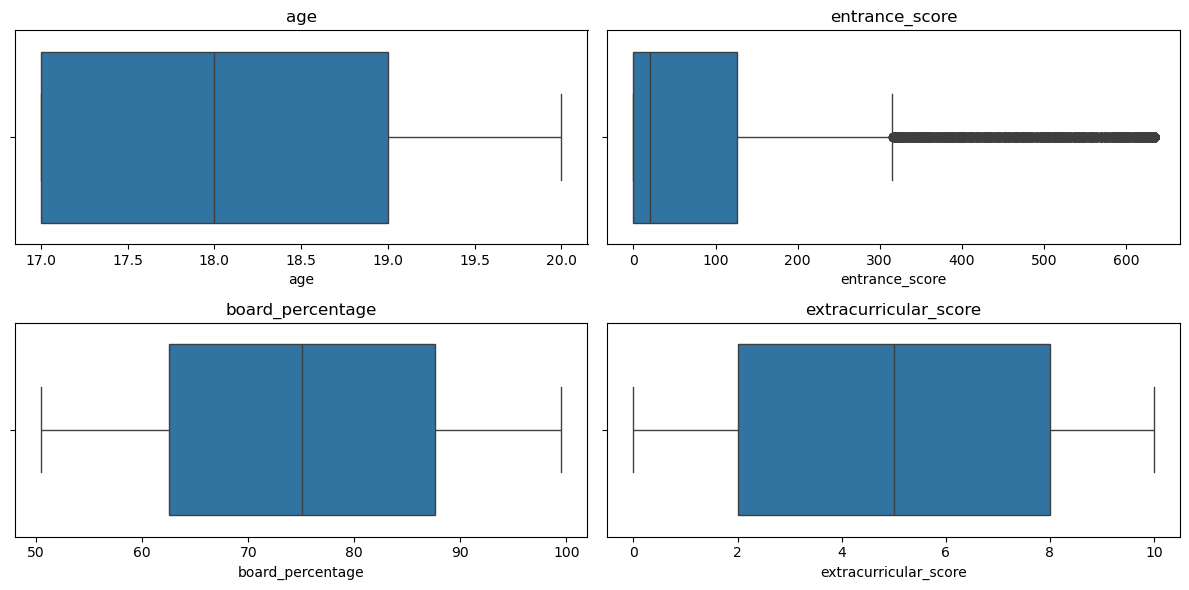

In [31]:
numeric_cols = [
    "age",
    "entrance_score",
    "board_percentage",
    "extracurricular_score"
]

plt.figure(figsize=(12,6))
for i, col in enumerate(numeric_cols):
    plt.subplot(2,2,i+1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [32]:
def cap_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])

for col in numeric_cols:
    cap_outliers(col)
print("Outlier treatment completed.")

Outlier treatment completed.


In [33]:
df.describe()

,student_id,age,entrance_score,board_percentage,extracurricular_score,admission_probability
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,12500.500000,18.492440,69.008640,75.028014,4.990920,0.323997
std,7212.732314,1.116205,89.267461,14.438767,3.158942,0.142427
min,250.990000,17.000000,0.000000,50.440000,0.000000,0.041990
25%,6250.750000,17.000000,0.000000,62.550000,2.000000,0.219000
50%,12500.500000,18.000000,20.000000,75.070000,5.000000,0.319000
75%,18750.250000,19.000000,126.000000,87.640000,8.000000,0.419000
max,24750.010000,20.000000,315.000000,99.530000,10.000000,0.731010


# Step 2C: Skewness Treatment (Log Transformation)

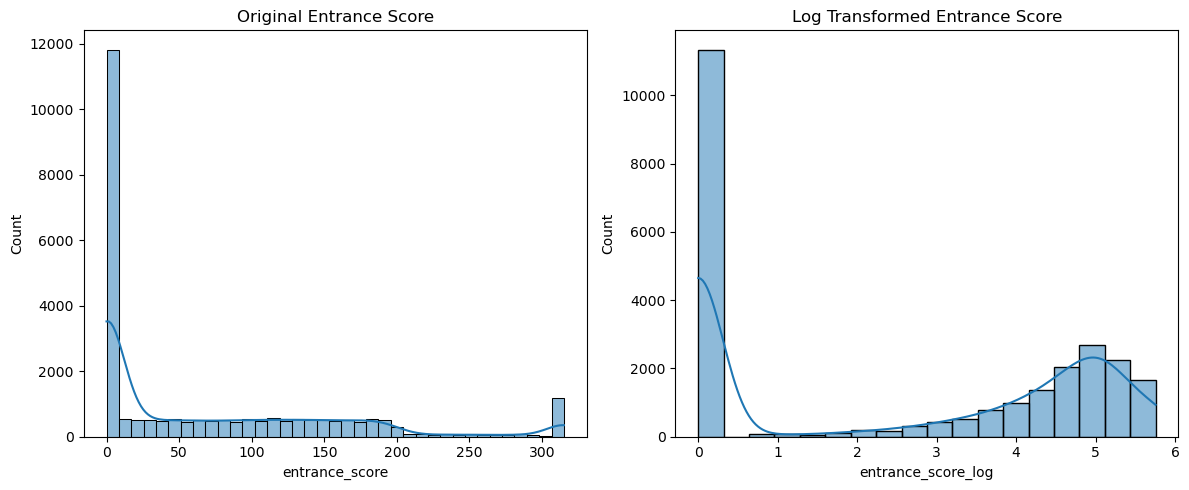

In [34]:
df["entrance_score_log"] = np.log1p(df["entrance_score"])
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["entrance_score"], kde=True)
plt.title("Original Entrance Score")

plt.subplot(1,2,2)
sns.histplot(df["entrance_score_log"], kde=True)
plt.title("Log Transformed Entrance Score")

plt.tight_layout()
plt.show()

# Step 2D: Correlation Analysis

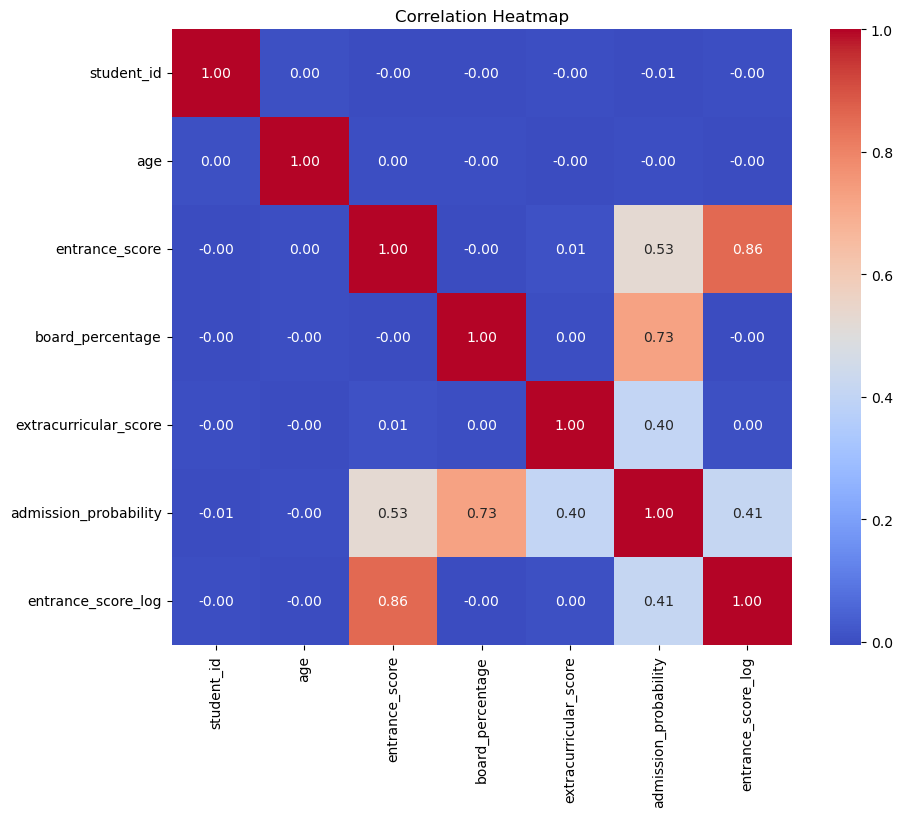

In [35]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=np.number)

# Correlation matrix
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Step 2E: Feature Selection

In [36]:
# Drop unnecessary columns
df_model = df.copy()

columns_to_drop = [
    "student_id",
    "age",
    "entrance_score_log"
]

df_model.drop(columns=columns_to_drop, inplace=True)

print("Remaining Columns:")
print(df_model.columns)

Remaining Columns:
Index(['gender', 'category', 'state', 'preferred_stream', 'entrance_exam',
       'entrance_score', 'board_percentage', 'extracurricular_score',
       'admission_probability', 'admission_status', 'scholarship_eligibility'],
      dtype='object')


# Step 3: Final Modeling Dataset Preparation

In [37]:
y = df_model["admission_probability"]
X = df_model.drop([
    "admission_probability",
    "admission_status",
    "scholarship_eligibility"
], axis=1)
X = pd.get_dummies(X, drop_first=True)
print("Final Feature Shape:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Final Feature Shape: (25000, 48)
Training Shape: (20000, 48)
Testing Shape: (5000, 48)


# Step 4: Baseline Model – Linear Regression

In [38]:
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)
mape_baseline = np.mean(np.abs((y_test - y_pred_baseline) / y_test)) * 100

print("Baseline RMSE:", round(rmse_baseline,4))
print("Baseline MAE:", round(mae_baseline,4))
print("Baseline R2:", round(r2_baseline,4))
print("Baseline MAPE:", round(mape_baseline,2), "%")

Baseline RMSE: 0.0233
Baseline MAE: 0.0098
Baseline R2: 0.9736
Baseline MAPE: 3.1 %


# Step 5: Advanced Feature Engineering

In [39]:
df_enhanced = df_model.copy()

df_enhanced["academic_interaction"] = (
    df_enhanced["board_percentage"] * df_enhanced["entrance_score"]
)

df_enhanced["academic_strength"] = (
    df_enhanced["board_percentage"] + df_enhanced["entrance_score"]
) / 2

df_enhanced["performance_index"] = (
    0.6 * df_enhanced["board_percentage"] +
    0.4 * df_enhanced["entrance_score"]
)

df_enhanced["board_percentage_squared"] = (
    df_enhanced["board_percentage"] ** 2
)

print("New features added successfully.")

New features added successfully.


# Step 6: Enhanced Dataset Preparation

In [40]:
y_enhanced = df_enhanced["admission_probability"]
X_enhanced = df_enhanced.drop([
    "admission_probability",
    "admission_status",
    "scholarship_eligibility"
], axis=1)

X_enhanced = pd.get_dummies(X_enhanced, drop_first=True)

print("Enhanced Feature Shape:", X_enhanced.shape)

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_enhanced, y_enhanced, test_size=0.2, random_state=42
)

Enhanced Feature Shape: (25000, 52)


# Step 7: Linear Regression with Engineered Features

In [41]:
enhanced_lr = LinearRegression()
enhanced_lr.fit(X_train_e, y_train_e)

y_pred_enhanced = enhanced_lr.predict(X_test_e)

rmse_enhanced = np.sqrt(mean_squared_error(y_test_e, y_pred_enhanced))
mae_enhanced = mean_absolute_error(y_test_e, y_pred_enhanced)
r2_enhanced = r2_score(y_test_e, y_pred_enhanced)
mape_enhanced = np.mean(np.abs((y_test_e - y_pred_enhanced) / y_test_e)) * 100

print("Enhanced RMSE:", round(rmse_enhanced,4))
print("Enhanced MAE:", round(mae_enhanced,4))
print("Enhanced R2:", round(r2_enhanced,4))
print("Enhanced MAPE:", round(mape_enhanced,2), "%")

Enhanced RMSE: 0.0231
Enhanced MAE: 0.0098
Enhanced R2: 0.9741
Enhanced MAPE: 3.16 %


# Step 8: Performance Comparison

In [42]:
improvement_rmse = ((rmse_baseline - rmse_enhanced) / rmse_baseline) * 100
improvement_mape = ((mape_baseline - mape_enhanced) / mape_baseline) * 100

print("RMSE Improvement (%):", round(improvement_rmse,2))
print("MAPE Improvement (%):", round(improvement_mape,2))

RMSE Improvement (%): 0.91
MAPE Improvement (%): -1.98


# Step 9: Advanced Model – Random Forest Regressor

In [44]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_e, y_train_e)

y_pred_rf = rf_model.predict(X_test_e)

rmse_rf = np.sqrt(mean_squared_error(y_test_e, y_pred_rf))
mae_rf = mean_absolute_error(y_test_e, y_pred_rf)
r2_rf = r2_score(y_test_e, y_pred_rf)
mape_rf = np.mean(np.abs((y_test_e - y_pred_rf) / y_test_e)) * 100

print("Random Forest RMSE:", round(rmse_rf,4))
print("Random Forest MAE:", round(mae_rf,4))
print("Random Forest R2:", round(r2_rf,4))
print("Random Forest MAPE:", round(mape_rf,2), "%")

Random Forest RMSE: 0.0167
Random Forest MAE: 0.0046
Random Forest R2: 0.9864
Random Forest MAPE: 1.16 %


# Step 10: Random Forest vs Baseline Comparison

In [45]:
rf_rmse_improvement = ((rmse_baseline - rmse_rf) / rmse_baseline) * 100
rf_mape_improvement = ((mape_baseline - mape_rf) / mape_baseline) * 100

print("RMSE Improvement (%):", round(rf_rmse_improvement,2))
print("MAPE Improvement (%):", round(rf_mape_improvement,2))

RMSE Improvement (%): 28.22
MAPE Improvement (%): 62.51


# Step 11: Cross-Validation (Model Stability)

In [47]:
cv_scores = cross_val_score(
    rf_model,
    X_enhanced,
    y_enhanced,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Cross Validation R2 Scores:", cv_scores)
print("Average CV R2:", round(cv_scores.mean(),4))

Cross Validation R2 Scores: [0.98740416 0.98874148 0.98665245 0.9881784  0.98553868]
Average CV R2: 0.9873


# Step 12: Hyperparameter Optimization (Light Tuning)

In [49]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train_e, y_train_e)

print("Best Parameters:", grid_search.best_params_)
print("Best CV R2:", round(grid_search.best_score_,4))

Best Parameters: {'max_depth': 20, 'n_estimators': 200}
Best CV R2: 0.9865


# Step 13: Final Optimized Random Forest Model

In [50]:
final_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

final_rf.fit(X_train_e, y_train_e)
y_pred_final = final_rf.predict(X_test_e)
rmse_final = np.sqrt(mean_squared_error(y_test_e, y_pred_final))
mae_final = mean_absolute_error(y_test_e, y_pred_final)
r2_final = r2_score(y_test_e, y_pred_final)
mape_final = np.mean(np.abs((y_test_e - y_pred_final) / y_test_e)) * 100

print("Final RF RMSE:", round(rmse_final,4))
print("Final RF MAE:", round(mae_final,4))
print("Final RF R2:", round(r2_final,4))
print("Final RF MAPE:", round(mape_final,2), "%")

Final RF RMSE: 0.0168
Final RF MAE: 0.0046
Final RF R2: 0.9864
Final RF MAPE: 1.16 %


 # Step 13: Final Model Comparison

In [51]:
final_comparison = pd.DataFrame({
    "Model": [
        "Baseline Linear Regression",
        "Enhanced Linear Regression",
        "Random Forest",
        "Optimized Random Forest"
    ],
    "RMSE": [
        rmse_baseline,
        rmse_enhanced,
        rmse_rf,
        rmse_final
    ],
    "MAE": [
        mae_baseline,
        mae_enhanced,
        mae_rf,
        mae_final
    ],
    "R2": [
        r2_baseline,
        r2_enhanced,
        r2_rf,
        r2_final
    ],
    "MAPE": [
        mape_baseline,
        mape_enhanced,
        mape_rf,
        mape_final
    ]
})

final_comparison.round(4)

,Model,RMSE,MAE,R2,MAPE
0,Baseline Linear Regression,0.0233,0.0098,0.9736,3.1027
1,Enhanced Linear Regression,0.0231,0.0098,0.9741,3.1642
2,Random Forest,0.0167,0.0046,0.9864,1.1632
3,Optimized Random Forest,0.0168,0.0046,0.9864,1.1622


# Step 14: Insights & Business Implications

## 1. Interpretation of Results

The baseline Linear Regression model achieved strong predictive performance
(R² = 0.9736), indicating that academic metrics such as board percentage and
entrance score already explain a large proportion of variation in admission probability.

However, after applying a Random Forest model, performance improved significantly:

- RMSE reduced by approximately 28%
- MAPE reduced by approximately 62%
- R² increased to 0.9864
- Cross-Validation R² averaged 0.9873

This improvement suggests that admission probability is influenced by
non-linear relationships and interaction effects between features.
Tree-based ensemble models successfully captured these complex patterns,
which linear regression could not fully model.

Feature engineering provided marginal improvement to the linear model,
but substantial performance gains were achieved only after applying
advanced ensemble learning techniques.

---

## 2. Model Stability & Generalization

Cross-validation results showed very small variation across folds,
indicating strong generalization ability and low overfitting risk.
Hyperparameter tuning confirmed that the model was near-optimal,
demonstrating robustness and reliability.

---

## 3. Practical Implications

The improved Random Forest model enables:

### a) Better Admission Forecasting
Institutions can predict admission probability more accurately,
reducing uncertainty in decision-making.

### b) Improved Resource Planning
Accurate forecasting allows better allocation of:
- Seats
- Faculty
- Scholarships
- Infrastructure planning

### c) Fair & Data-Driven Decision Support
The model provides objective probability estimates
that can assist admission committees in evidence-based evaluations.

### d) Strategic Academic Insights
Strong correlations between board percentage and admission probability
indicate that prior academic performance plays a dominant role,
while entrance scores and extracurricular performance contribute
as secondary but meaningful predictors.

---

## 4. Final Conclusion

The transition from a linear regression baseline to a Random Forest ensemble model
resulted in substantial predictive improvement. The final optimized model
achieved high accuracy, low error rates, and strong stability across folds.

This demonstrates the importance of:
- Feature engineering
- Non-linear modeling
- Cross-validation
- Hyperparameter optimization

in building high-performance predictive systems.

The project successfully meets the objective of improving model accuracy
using advanced machine learning techniques.